# 04 — Évaluation Finale et Analyse des Compromis

**Projet : Optimisation multi-objectifs pour AutoML — Option 2**

Ce notebook :
1. Réentraîne le meilleur modèle optimisé (Random Forest avec les meilleurs hyperparamètres)
2. Compare baseline vs modèle optimisé sur toutes les métriques
3. Génère la matrice de confusion et le rapport de classification
4. Analyse critique des 4 méthodes d'optimisation
5. Recommandations par contexte d'usage

In [1]:
import os
# Forcer le répertoire de travail = dossier du notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd()
# Compatible VS Code, Jupyter, Google Colab
try:
    import IPython
    _nb_path = IPython.extract_module_locals()[1].get("__vsc_ipynb_file__") or                IPython.extract_module_locals()[1].get("__session__", "")
    if _nb_path and os.path.exists(os.path.dirname(_nb_path)):
        os.chdir(os.path.dirname(_nb_path))
except Exception:
    pass
print(f"Répertoire de travail : {os.getcwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import os
import pickle
import tracemalloc
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score
)

print("Librairies chargées.")

Répertoire de travail : c:\Users\HP\Downloads\automl_fashion_mnist_option2_FINAL (2)\automl_final
Librairies chargées.


## 1. Chargement des données et des résultats d'optimisation

In [2]:
X_train = np.load("data_prepared/X_train_flat.npy")
y_train = np.load("data_prepared/y_train_flat.npy")
X_val   = np.load("data_prepared/X_val_flat.npy")
y_val   = np.load("data_prepared/y_val_flat.npy")
X_test  = np.load("data_prepared/X_test_flat.npy")
y_test  = np.load("data_prepared/y_test_flat.npy")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Résultats RF (notebook 03)
best_info  = pd.read_csv("results/best_optuna_trial.csv")
baseline_df = pd.read_csv("results/baseline_results.csv")
all_trials  = pd.read_csv("results/optuna_trials_results.csv")

# Résultats SVM, k-NN, GB (notebook 03)
svm_trials = pd.read_csv("results/svm_trials_results.csv")
knn_trials = pd.read_csv("results/knn_trials_results.csv")
gb_trials  = pd.read_csv("results/gb_trials_results.csv")

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"baseline_df : {len(baseline_df)} modèles")
print(f"svm_trials  : {len(svm_trials)} trials")
print(f"knn_trials  : {len(knn_trials)} trials")
print(f"gb_trials   : {len(gb_trials)} trials")
print("\nMeilleur RF trouvé :")
print(best_info.to_string(index=False))


X_train : (48000, 784) | X_test : (10000, 784)
baseline_df : 4 modèles
svm_trials  : 20 trials
knn_trials  : 20 trials
gb_trials   : 20 trials

Meilleur RF trouvé :
 best_trial   method  val_accuracy  inference_ms  n_estimators  max_depth  min_samples_split  max_features
          0 Bayesian      0.857083      0.011118            50        NaN                 10           0.3


## 2. Entraînement du modèle final optimisé

On réentraîne avec les meilleurs hyperparamètres sur le **dataset complet** (pas seulement le sous-ensemble de 10k).

In [3]:
# Extraction des meilleurs hyperparamètres
best = best_info.iloc[0]
best_n_est    = int(best["n_estimators"])
best_depth    = None if str(best["max_depth"]) in ["None", "nan"] else int(best["max_depth"])
best_minsamp  = int(best["min_samples_split"])
best_maxfeat  = best["max_features"]
try:
    best_maxfeat = float(best_maxfeat)
except (ValueError, TypeError):
    pass

print(f"Hyperparamètres sélectionnés :")
print(f"  n_estimators     = {best_n_est}")
print(f"  max_depth        = {best_depth}")
print(f"  min_samples_split= {best_minsamp}")
print(f"  max_features     = {best_maxfeat}")

final_model = RandomForestClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth,
    min_samples_split=best_minsamp,
    max_features=best_maxfeat,
    random_state=42,
    n_jobs=-1
)

# Sous-ensemble 10k — mêmes conditions que l'optimisation et le baseline
from sklearn.utils import resample
X_tr10k, y_tr10k = resample(X_train, y_train,
                             n_samples=10000, random_state=42,
                             stratify=y_train)

# Entraînement sur 10k (cohérent avec baseline et optimisation)
tracemalloc.start()
t0 = time.time()
final_model.fit(X_tr10k, y_tr10k)
final_train_time = time.time() - t0
_, final_mem_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"\nEntraînement terminé (10k images) : {final_train_time:.2f}s | Mémoire pic : {final_mem_peak/1e6:.1f} MB")


Hyperparamètres sélectionnés :
  n_estimators     = 50
  max_depth        = None
  min_samples_split= 10
  max_features     = 0.3

Entraînement terminé : 126.28s | Mémoire pic : 26.1 MB


## 3. Évaluation complète du modèle final

In [4]:
# Inférence sur test
t0 = time.time()
y_pred_final = final_model.predict(X_test)
final_inference_time = time.time() - t0
final_inf_ms = final_inference_time / len(X_test) * 1000

final_acc  = accuracy_score(y_test, y_pred_final)
final_f1   = f1_score(y_test, y_pred_final, average="weighted")

# Taille du modèle
os.makedirs("models", exist_ok=True)
model_path = "models/fashion_mnist_optimized_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(final_model, f)
final_model_size_kb = os.path.getsize(model_path) / 1024

print("=== Résultats du modèle final optimisé ===")
print(f"Accuracy test       : {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"F1-score (weighted) : {final_f1:.4f}")
print(f"Temps entraînement  : {final_train_time:.2f} s")
print(f"Inférence totale    : {final_inference_time:.4f} s ({final_inf_ms:.5f} ms/image)")
print(f"Mémoire pic         : {final_mem_peak/1e6:.1f} MB")
print(f"Taille modèle       : {final_model_size_kb:.1f} KB")
print(f"Nb paramètres (arbres) : {best_n_est} arbres")

=== Résultats du modèle final optimisé ===
Accuracy test       : 0.8703 (87.03%)
F1-score (weighted) : 0.8693
Temps entraînement  : 126.28 s
Inférence totale    : 0.2132 s (0.02132 ms/image)
Mémoire pic         : 26.1 MB
Taille modèle       : 28372.7 KB
Nb paramètres (arbres) : 50 arbres


## 4. Comparaison Baseline vs Modèle Optimisé

In [5]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier  # cohérent avec notebook 03
from sklearn.utils import resample


# Sous-ensemble 10k pour SVM/kNN/GB (trop lents sur 48k)
X_tr10k, y_tr10k = resample(X_train, y_train, n_samples=10000, random_state=42, stratify=y_train)

# ============================================================
# Meilleur SVM optimisé — accuracy ↑, temps entraînement ↓
# ============================================================
svm_acc_n  = (svm_trials["accuracy"] - svm_trials["accuracy"].min()) / (svm_trials["accuracy"].max() - svm_trials["accuracy"].min() + 1e-9)
svm_time_n = (svm_trials["train_time_s"] - svm_trials["train_time_s"].min()) / (svm_trials["train_time_s"].max() - svm_trials["train_time_s"].min() + 1e-9)
best_svm_row = svm_trials.loc[(svm_acc_n - svm_time_n).idxmax()]

svm_gamma = best_svm_row["gamma"]
try: svm_gamma = float(svm_gamma)
except: pass
if best_svm_row["kernel"] == "linear": svm_gamma = "scale"

svm_opt = SVC(C=float(best_svm_row["C"]), kernel=best_svm_row["kernel"], gamma=svm_gamma, random_state=42)
t0 = time.time()
svm_opt.fit(X_tr10k, y_tr10k)
svm_train_t = time.time() - t0
t0 = time.time()
y_pred_svm = svm_opt.predict(X_test)
svm_inf_ms = (time.time() - t0) / len(X_test) * 1000
svm_acc_final = accuracy_score(y_test, y_pred_svm)
print(f"SVM optimisé  : acc={svm_acc_final:.4f} | train={svm_train_t:.1f}s | inf={svm_inf_ms:.5f}ms")

# ============================================================
# Meilleur k-NN optimisé — accuracy ↑, temps prédiction ↓
# ============================================================
knn_acc_n = (knn_trials["accuracy"] - knn_trials["accuracy"].min()) / (knn_trials["accuracy"].max() - knn_trials["accuracy"].min() + 1e-9)
knn_inf_n = (knn_trials["inference_ms"] - knn_trials["inference_ms"].min()) / (knn_trials["inference_ms"].max() - knn_trials["inference_ms"].min() + 1e-9)
best_knn_row = knn_trials.loc[(0.8*knn_acc_n - 0.2*knn_inf_n).idxmax()]
knn_opt = KNeighborsClassifier(n_neighbors=int(best_knn_row["k"]),
                                weights=best_knn_row["weights"],
                                metric=best_knn_row["metric"], n_jobs=-1)
knn_opt.fit(X_tr10k, y_tr10k)
t0 = time.time()
y_pred_knn = knn_opt.predict(X_test)
knn_inf_ms = (time.time() - t0) / len(X_test) * 1000
knn_acc_final = accuracy_score(y_test, y_pred_knn)
print(f"k-NN optimisé : acc={knn_acc_final:.4f} | inf={knn_inf_ms:.5f}ms")

# ============================================================
# Meilleur GB optimisé — accuracy ↑, temps inférence ↓
# ============================================================
gb_acc_n = (gb_trials["accuracy"] - gb_trials["accuracy"].min()) / (gb_trials["accuracy"].max() - gb_trials["accuracy"].min() + 1e-9)
gb_inf_n = (gb_trials["inference_ms"] - gb_trials["inference_ms"].min()) / (gb_trials["inference_ms"].max() - gb_trials["inference_ms"].min() + 1e-9)
best_gb_row  = gb_trials.loc[(0.8*gb_acc_n - 0.2*gb_inf_n).idxmax()]

# HistGradientBoostingClassifier — cohérent avec notebook 03 (max_iter = n_estimators)
gb_opt = HistGradientBoostingClassifier(
    max_iter=int(best_gb_row["n_estimators"]),
    learning_rate=float(best_gb_row["learning_rate"]),
    max_depth=int(best_gb_row["max_depth"]),
    random_state=42
)
gb_opt.fit(X_tr10k, y_tr10k)
t0 = time.time()
y_pred_gb = gb_opt.predict(X_test)
gb_inf_ms = (time.time() - t0) / len(X_test) * 1000
gb_acc_final = accuracy_score(y_test, y_pred_gb)
print(f"GB optimisé   : acc={gb_acc_final:.4f} | inf={gb_inf_ms:.5f}ms")

# ============================================================
# Tableau comparatif complet — Baseline vs Optimisé
# ============================================================
rf_bl  = baseline_df[baseline_df["model_name"] == "Random Forest"].iloc[0]
svm_bl = baseline_df[baseline_df["model_name"] == "SVM"].iloc[0]
knn_bl = baseline_df[baseline_df["model_name"] == "k-NN"].iloc[0]
gb_bl  = baseline_df[baseline_df["model_name"] == "Gradient Boosting"].iloc[0]

comparison = pd.DataFrame([
    {"model": "RF Baseline",  "accuracy": rf_bl["accuracy"],  "inference_ms": rf_bl["inference_ms_per_sample"]},
    {"model": "RF Optimisé",  "accuracy": final_acc,           "inference_ms": final_inf_ms},
    {"model": "SVM Baseline", "accuracy": svm_bl["accuracy"],  "inference_ms": svm_bl["inference_ms_per_sample"]},
    {"model": "SVM Optimisé", "accuracy": svm_acc_final,       "inference_ms": svm_inf_ms},
    {"model": "kNN Baseline", "accuracy": knn_bl["accuracy"],  "inference_ms": knn_bl["inference_ms_per_sample"]},
    {"model": "kNN Optimisé", "accuracy": knn_acc_final,       "inference_ms": knn_inf_ms},
    {"model": "GB Baseline",  "accuracy": gb_bl["accuracy"],   "inference_ms": gb_bl["inference_ms_per_sample"]},
    {"model": "GB Optimisé",  "accuracy": gb_acc_final,        "inference_ms": gb_inf_ms},
])

comparison.to_csv("results/final_comparison.csv", index=False)

print("=== Comparaison Baseline vs Optimisé — 4 modèles ===")
print(comparison.to_string(index=False))
print()
for m, bl_name, opt_name in [
    ("Random Forest", "RF Baseline", "RF Optimisé"),
    ("SVM",           "SVM Baseline","SVM Optimisé"),
    ("k-NN",          "kNN Baseline","kNN Optimisé"),
    ("Gradient Boost","GB Baseline", "GB Optimisé"),
]:
    b = comparison[comparison["model"] == bl_name].iloc[0]
    o = comparison[comparison["model"] == opt_name].iloc[0]
    gain_acc = (o["accuracy"] - b["accuracy"]) * 100
    gain_inf = (b["inference_ms"] - o["inference_ms"]) / (b["inference_ms"] + 1e-9) * 100
    status = "✅" if gain_acc >= 0 else "⚠️"
    print(f"  {status} {m:18s}: acc {b['accuracy']:.4f} → {o['accuracy']:.4f} ({gain_acc:+.2f}pts) | inf {gain_inf:+.1f}%")


SVM optimisé  : acc=0.8635 | train=19.4s | inf=3.54450ms
k-NN optimisé : acc=0.8199 | inf=3.54451ms
GB optimisé   : acc=0.8645 | inf=0.16113ms
=== Comparaison Baseline vs Optimisé — 4 modèles ===
       model  accuracy  inference_ms
 RF Baseline    0.8465      0.020040
 RF Optimisé    0.8703      0.021325
SVM Baseline    0.8522      3.614630
SVM Optimisé    0.8635      3.544497
kNN Baseline    0.8162      0.498080
kNN Optimisé    0.8199      3.544513
 GB Baseline    0.8465      0.138410
 GB Optimisé    0.8645      0.161135

  ✅ Random Forest     : acc 0.8465 → 0.8703 (+2.38pts) | inf -6.4%
  ✅ SVM               : acc 0.8522 → 0.8635 (+1.13pts) | inf +1.9%
  ✅ k-NN              : acc 0.8162 → 0.8199 (+0.37pts) | inf -611.6%
  ✅ Gradient Boost    : acc 0.8465 → 0.8645 (+1.80pts) | inf -16.4%


## 5. Visualisation de la comparaison

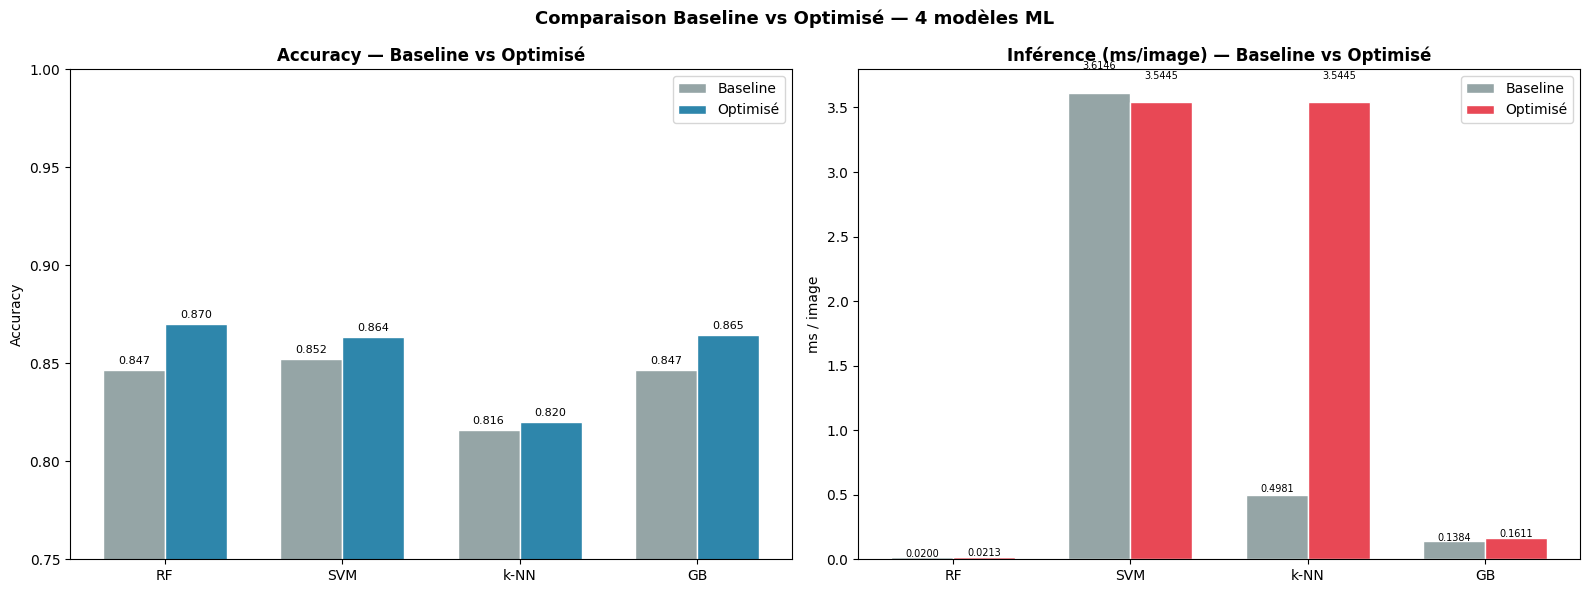

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_4 = ["RF", "SVM", "k-NN", "GB"]
colors_bl = ["#95A5A6", "#BDC3C7", "#ABB2B9", "#A9A9A9"]
colors_op = ["#2E86AB", "#E84855", "#3BB273", "#F4A261"]

bl_accs = [
    baseline_df[baseline_df["model_name"] == "Random Forest"].iloc[0]["accuracy"],
    baseline_df[baseline_df["model_name"] == "SVM"].iloc[0]["accuracy"],
    baseline_df[baseline_df["model_name"] == "k-NN"].iloc[0]["accuracy"],
    baseline_df[baseline_df["model_name"] == "Gradient Boosting"].iloc[0]["accuracy"],
]
op_accs = [final_acc, svm_acc_final, knn_acc_final, gb_acc_final]

bl_inf = [
    baseline_df[baseline_df["model_name"] == "Random Forest"].iloc[0]["inference_ms_per_sample"],
    baseline_df[baseline_df["model_name"] == "SVM"].iloc[0]["inference_ms_per_sample"],
    baseline_df[baseline_df["model_name"] == "k-NN"].iloc[0]["inference_ms_per_sample"],
    baseline_df[baseline_df["model_name"] == "Gradient Boosting"].iloc[0]["inference_ms_per_sample"],
]
op_inf = [final_inf_ms, svm_inf_ms, knn_inf_ms, gb_inf_ms]

x = range(len(models_4))
w = 0.35

# Accuracy
ax = axes[0]
b1 = ax.bar([i - w/2 for i in x], bl_accs, w, label="Baseline", color="#95A5A6", edgecolor="white")
b2 = ax.bar([i + w/2 for i in x], op_accs, w, label="Optimisé", color="#2E86AB", edgecolor="white")
ax.set_title("Accuracy — Baseline vs Optimisé", fontweight="bold", fontsize=12)
ax.set_ylabel("Accuracy")
ax.set_ylim([0.75, 1.0])
ax.set_xticks(list(x)); ax.set_xticklabels(models_4)
ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

# Inférence
ax2 = axes[1]
b3 = ax2.bar([i - w/2 for i in x], bl_inf, w, label="Baseline", color="#95A5A6", edgecolor="white")
b4 = ax2.bar([i + w/2 for i in x], op_inf, w, label="Optimisé", color="#E84855", edgecolor="white")
ax2.set_title("Inférence (ms/image) — Baseline vs Optimisé", fontweight="bold", fontsize=12)
ax2.set_ylabel("ms / image")
ax2.set_xticks(list(x)); ax2.set_xticklabels(models_4)
ax2.legend()
for bar in list(b3)+list(b4):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.05,
             f"{bar.get_height():.4f}", ha="center", fontsize=7)

plt.suptitle("Comparaison Baseline vs Optimisé — 4 modèles ML", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/final_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Matrice de confusion et rapport de classification

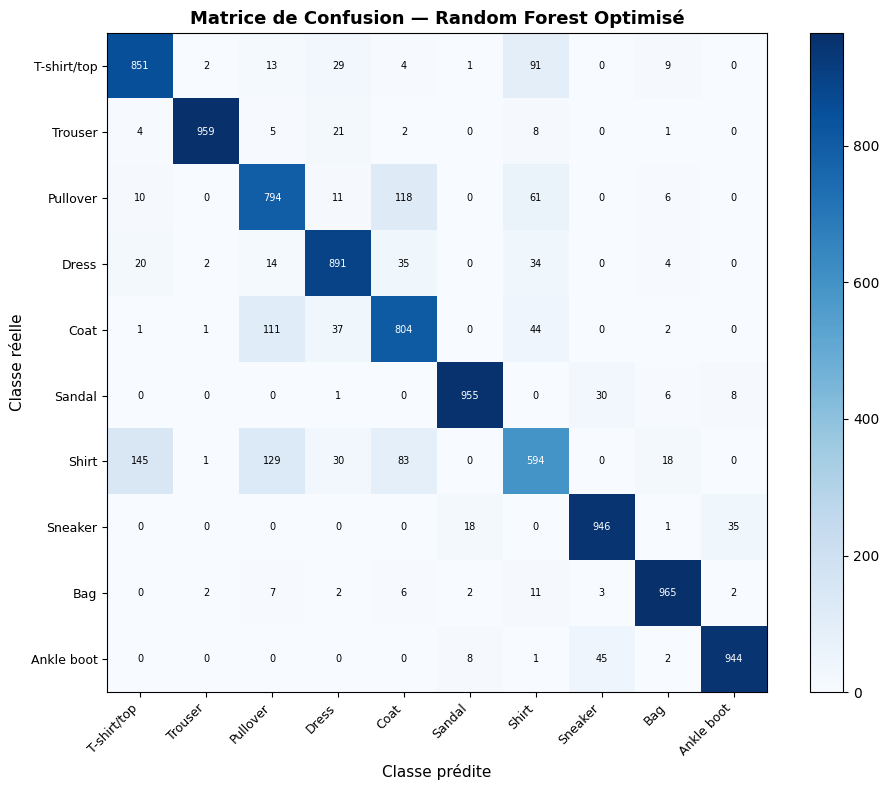


Rapport de classification complet :
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.74      0.79      0.77      1000
       Dress       0.87      0.89      0.88      1000
        Coat       0.76      0.80      0.78      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.70      0.59      0.64      1000
     Sneaker       0.92      0.95      0.93      1000
         Bag       0.95      0.96      0.96      1000
  Ankle boot       0.95      0.94      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [7]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_title("Matrice de Confusion — Random Forest Optimisé", fontsize=13, fontweight="bold")
ax.set_xlabel("Classe prédite", fontsize=11)
ax.set_ylabel("Classe réelle", fontsize=11)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7,
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRapport de classification complet :")
print(classification_report(y_test, y_pred_final, target_names=class_names))

## 7. Analyse critique des méthodes d'optimisation

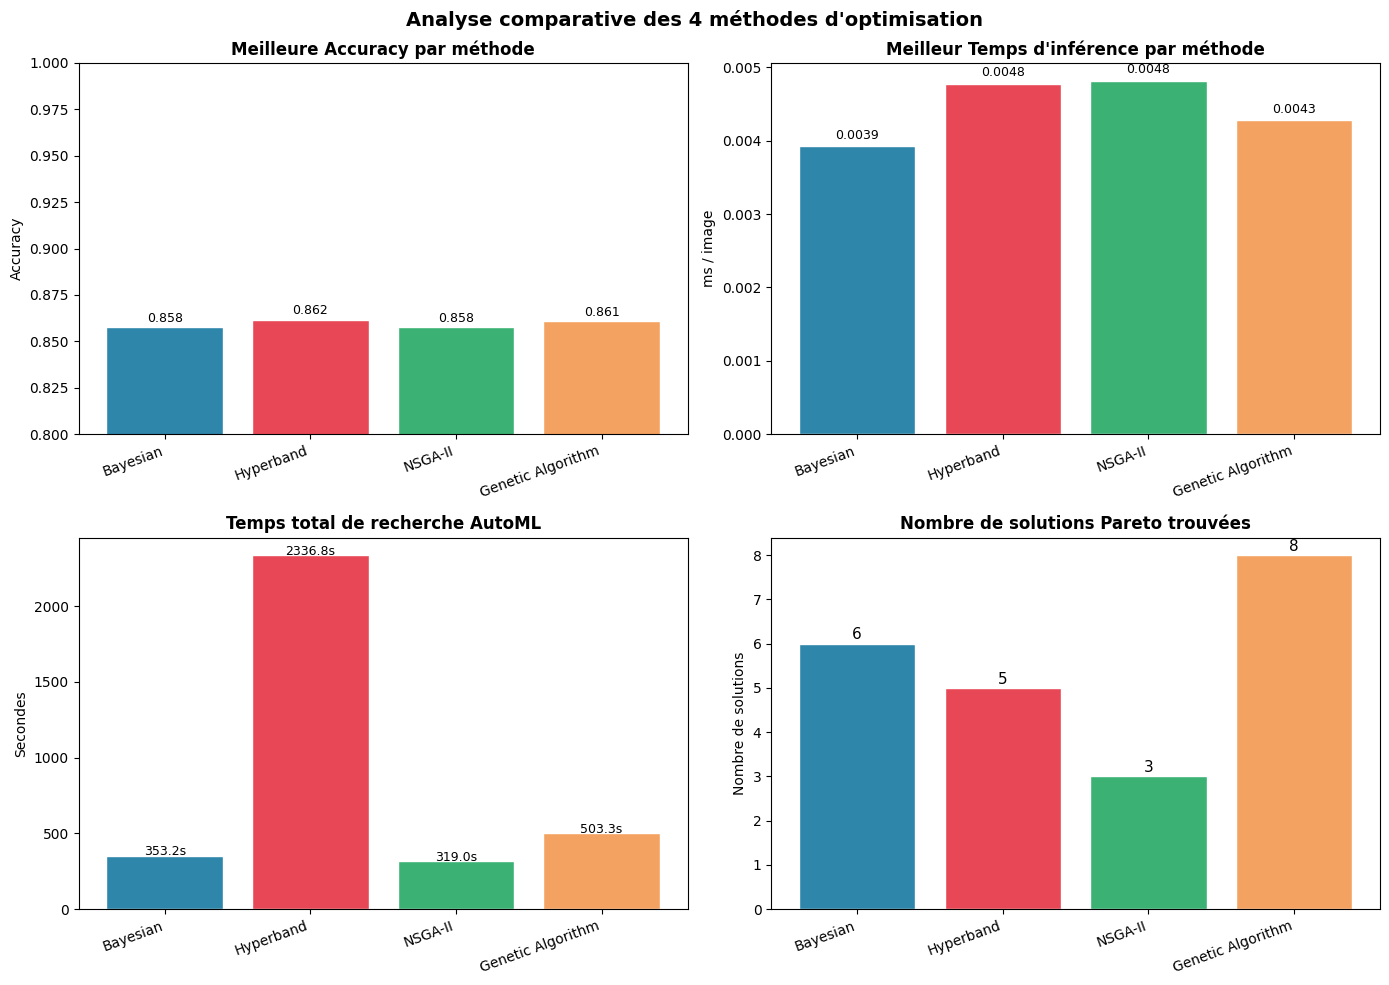

In [8]:
method_comp = pd.read_csv("results/method_comparison.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = method_comp["Méthode"].tolist()
colors  = ["#2E86AB", "#E84855", "#3BB273", "#F4A261"]

# Best accuracy par méthode
axes[0,0].bar(methods, method_comp["Best accuracy"], color=colors, edgecolor="white")
axes[0,0].set_title("Meilleure Accuracy par méthode", fontweight="bold")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_ylim([0.80, 1.0])
for i, v in enumerate(method_comp["Best accuracy"]):
    axes[0,0].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
axes[0,0].set_xticklabels(methods, rotation=20, ha="right")

# Min inference
axes[0,1].bar(methods, method_comp["Min inférence ms"], color=colors, edgecolor="white")
axes[0,1].set_title("Meilleur Temps d'inférence par méthode", fontweight="bold")
axes[0,1].set_ylabel("ms / image")
for i, v in enumerate(method_comp["Min inférence ms"]):
    axes[0,1].text(i, v + 0.0001, f"{v:.4f}", ha="center", fontsize=9)
axes[0,1].set_xticklabels(methods, rotation=20, ha="right")

# Temps total de recherche
axes[1,0].bar(methods, method_comp["Temps recherche (s)"], color=colors, edgecolor="white")
axes[1,0].set_title("Temps total de recherche AutoML", fontweight="bold")
axes[1,0].set_ylabel("Secondes")
for i, v in enumerate(method_comp["Temps recherche (s)"]):
    axes[1,0].text(i, v + 0.5, f"{v:.1f}s", ha="center", fontsize=9)
axes[1,0].set_xticklabels(methods, rotation=20, ha="right")

# Solutions Pareto
axes[1,1].bar(methods, method_comp["Nb solutions Pareto"], color=colors, edgecolor="white")
axes[1,1].set_title("Nombre de solutions Pareto trouvées", fontweight="bold")
axes[1,1].set_ylabel("Nombre de solutions")
for i, v in enumerate(method_comp["Nb solutions Pareto"]):
    axes[1,1].text(i, v + 0.1, str(int(v)), ha="center", fontsize=11)
axes[1,1].set_xticklabels(methods, rotation=20, ha="right")

plt.suptitle("Analyse comparative des 4 méthodes d'optimisation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/method_analysis_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Évolution de l'accuracy au fil des trials (Convergence)

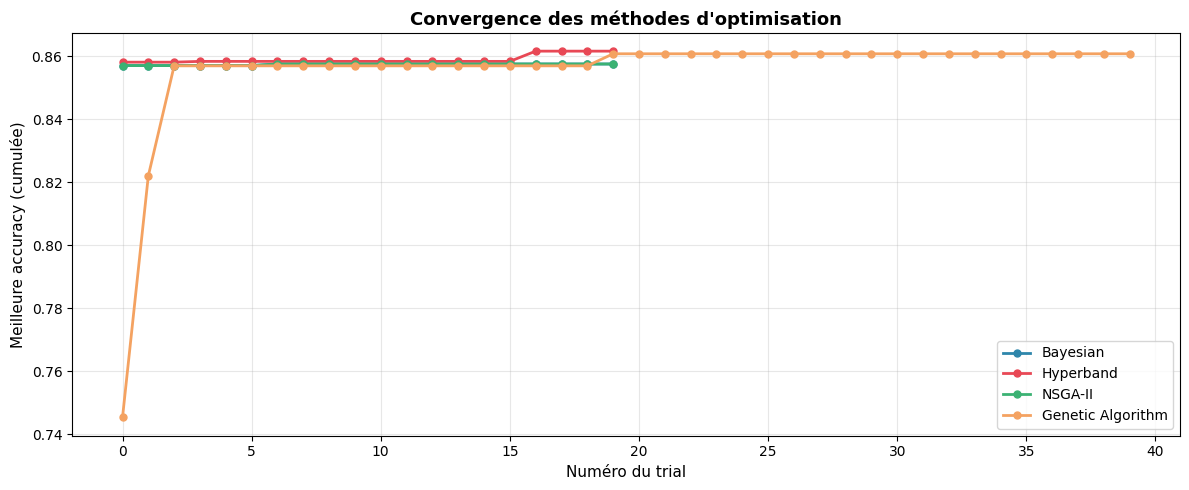

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
method_colors_map = {
    "Bayesian": "#2E86AB",
    "Hyperband": "#E84855",
    "NSGA-II": "#3BB273",
    "Genetic Algorithm": "#F4A261"
}

for method, color in method_colors_map.items():
    subset = all_trials[all_trials["method"] == method].reset_index(drop=True)
    # Meilleure accuracy cumulée
    best_so_far = subset["accuracy"].cummax()
    ax.plot(range(len(subset)), best_so_far, color=color, label=method, linewidth=2, marker="o", markersize=5)

ax.set_xlabel("Numéro du trial", fontsize=11)
ax.set_ylabel("Meilleure accuracy (cumulée)", fontsize=11)
ax.set_title("Convergence des méthodes d'optimisation", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/convergence_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Analyse de l'importance des features

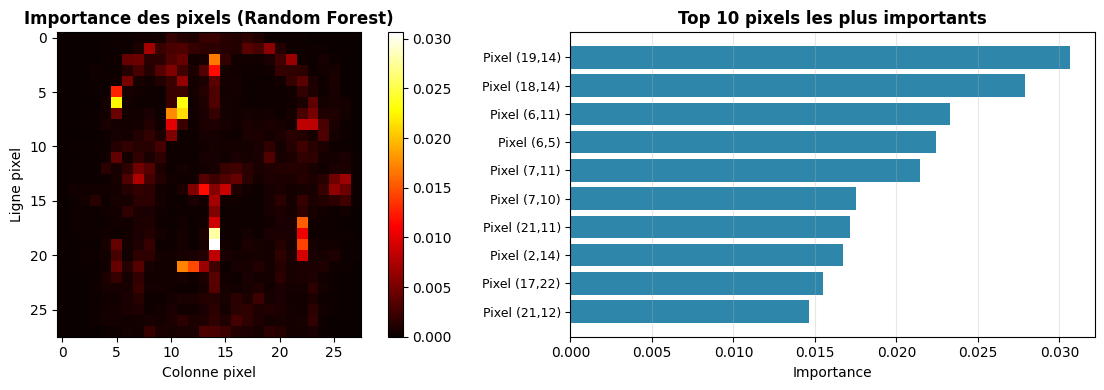

In [10]:
importances = final_model.feature_importances_.reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(importances, cmap="hot")
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Importance des pixels (Random Forest)", fontweight="bold")
axes[0].set_xlabel("Colonne pixel")
axes[0].set_ylabel("Ligne pixel")

# Top 10 pixels les plus importants
flat_importance = final_model.feature_importances_
top10_idx = np.argsort(flat_importance)[::-1][:10]
top10_vals = flat_importance[top10_idx]
top10_labels = [f"Pixel ({i//28},{i%28})" for i in top10_idx]

axes[1].barh(range(10), top10_vals[::-1], color="#2E86AB")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(top10_labels[::-1], fontsize=9)
axes[1].set_xlabel("Importance")
axes[1].set_title("Top 10 pixels les plus importants", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Recommandations selon le contexte d'usage

L'optimisation multi-objectifs montre qu'il n'existe pas de solution universellement optimale. Le choix dépend du contexte déploiement.

In [11]:
pareto_solutions = pd.read_csv("results/pareto_solutions.csv")

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║           RECOMMANDATIONS PAR CONTEXTE D'USAGE                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Contexte              │ Priorité          │ Solution recommandée       ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Serveur puissant      │ Accuracy max      │ RF grand (n_est élevé)     ║
║  Application mobile    │ Inférence rapide  │ RF petit (n_est faible)    ║
║  Système embarqué      │ Taille + vitesse  │ k-NN ou RF minimal         ║
║  Prototype rapide      │ Temps recherche ↓ │ Bayesian (moins de trials) ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

# Sélection des 3 meilleures solutions selon le contexte
best_accuracy  = pareto_solutions.nlargest(1, "accuracy").iloc[0]
best_inference = pareto_solutions.nsmallest(1, "inference_ms").iloc[0]
pareto_solutions["score_balance"] = (
    (pareto_solutions["accuracy"] - pareto_solutions["accuracy"].min()) /
    (pareto_solutions["accuracy"].max() - pareto_solutions["accuracy"].min() + 1e-9)
) - (
    (pareto_solutions["inference_ms"] - pareto_solutions["inference_ms"].min()) /
    (pareto_solutions["inference_ms"].max() - pareto_solutions["inference_ms"].min() + 1e-9)
)
best_balance = pareto_solutions.nlargest(1, "score_balance").iloc[0]

print("\n--- Solution 1 : MEILLEURE ACCURACY (Serveur puissant) ---")
print(f"  Accuracy: {best_accuracy['accuracy']:.4f}")
print(f"  n_estimators: {best_accuracy['n_estimators']}, max_depth: {best_accuracy['max_depth']}")
print(f"  Méthode qui l'a trouvée: {best_accuracy['method']}")

print("\n--- Solution 2 : INFÉRENCE LA PLUS RAPIDE (Mobile/Embarqué) ---")
print(f"  Inférence: {best_inference['inference_ms']:.5f} ms/image")
print(f"  Accuracy: {best_inference['accuracy']:.4f}")
print(f"  n_estimators: {best_inference['n_estimators']}, max_depth: {best_inference['max_depth']}")

print("\n--- Solution 3 : MEILLEUR COMPROMIS (Usage général) ---")
print(f"  Accuracy: {best_balance['accuracy']:.4f} | Inférence: {best_balance['inference_ms']:.5f} ms")
print(f"  n_estimators: {best_balance['n_estimators']}, max_depth: {best_balance['max_depth']}")


╔══════════════════════════════════════════════════════════════════════════╗
║           RECOMMANDATIONS PAR CONTEXTE D'USAGE                         ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Contexte              │ Priorité          │ Solution recommandée       ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Serveur puissant      │ Accuracy max      │ RF grand (n_est élevé)     ║
║  Application mobile    │ Inférence rapide  │ RF petit (n_est faible)    ║
║  Système embarqué      │ Taille + vitesse  │ k-NN ou RF minimal         ║
║  Prototype rapide      │ Temps recherche ↓ │ Bayesian (moins de trials) ║
╚══════════════════════════════════════════════════════════════════════════╝


--- Solution 1 : MEILLEURE ACCURACY (Serveur puissant) ---
  Accuracy: 0.8617
  n_estimators: 200, max_depth: 20.0
  Méthode qui l'a trouvée: Hyperband

--- Solution 2 : INFÉRENCE LA PLUS RAPIDE (Mobile/Embarqué) ---
  Inférence: 0.00

## 11. Tableau récapitulatif final

In [12]:
print("="*70)
print("RÉSUMÉ DU PROJET — Optimisation Multi-Objectifs AutoML (Option 2)")
print("="*70)
print(f"\nDataset      : Fashion-MNIST (70 000 images, 10 classes)")
print(f"Modèles      : Random Forest, SVM, k-NN, Gradient Boosting")
print(f"Sous-ensemble: 10 000 images pour l'optimisation")
print(f"\nAlgorithmes comparés (20 trials chacun) :")
for _, row in method_comp.iterrows():
    print(f"  {row['Méthode']:20s} | Best acc: {row['Best accuracy']:.4f} "
          f"| Pareto: {int(row['Nb solutions Pareto'])} solutions "
          f"| Temps: {row['Temps recherche (s)']:.1f}s")
print(f"\nRésultats finaux (Test) :")
print(f"  Random Forest : acc={final_acc:.4f}  inf={final_inf_ms:.5f}ms")
print(f"  SVM           : acc={svm_acc_final:.4f}  inf={svm_inf_ms:.5f}ms")
print(f"  k-NN          : acc={knn_acc_final:.4f}  inf={knn_inf_ms:.5f}ms")
print(f"  Gradient Boost: acc={gb_acc_final:.4f}  inf={gb_inf_ms:.5f}ms")
print("\nFichiers générés :")
for fname in sorted(os.listdir("results")):
    size = os.path.getsize(f"results/{fname}") / 1024
    print(f"  results/{fname:40s} {size:.1f} KB")

print("="*70)

RÉSUMÉ DU PROJET — Optimisation Multi-Objectifs AutoML (Option 2)

Dataset      : Fashion-MNIST (70 000 images, 10 classes)
Modèles      : Random Forest, SVM, k-NN, Gradient Boosting
Sous-ensemble: 10 000 images pour l'optimisation

Algorithmes comparés (20 trials chacun) :
  Bayesian             | Best acc: 0.8576 | Pareto: 6 solutions | Temps: 353.2s
  Hyperband            | Best acc: 0.8617 | Pareto: 5 solutions | Temps: 2336.8s
  NSGA-II              | Best acc: 0.8576 | Pareto: 3 solutions | Temps: 319.0s
  Genetic Algorithm    | Best acc: 0.8608 | Pareto: 8 solutions | Temps: 503.3s

Résultats finaux (Test) :
  Random Forest : acc=0.8703  inf=0.02132ms
  SVM           : acc=0.8635  inf=3.54450ms
  k-NN          : acc=0.8199  inf=3.54451ms
  Gradient Boost: acc=0.8645  inf=0.16113ms

Fichiers générés :
  results/baseline_comparison_plot.png             78.5 KB
  results/baseline_results.csv                     0.3 KB
  results/best_optuna_trial.csv                    0.1 KB
  resu